
A minimal runnable script that:
  * loads/creates placeholder organoid graphs,
  * builds the dataset,
  * trains with the two-phase sparse procedure,
  * prints evaluation metrics and top coefficients,
  * saves history to disk for later plotting.


In [31]:
import numpy as np
import matplotlib.pyplot as plt
import torch

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "training_data"

sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)

PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data


In [32]:
from src.data.io import load_graph_dataset_from_dir
from src.data.metadata import load_aux_metadata_for_dir, attach_metadata_to_graphs

# Load all organoids
data_dir = PROJECT_ROOT / "training_data" / "full_set"
graphs = load_graph_dataset_from_dir(str(data_dir))
print(f"Loaded {len(graphs)} organoids.")

meta = load_aux_metadata_for_dir(str(data_dir))
attached = attach_metadata_to_graphs(
    graphs,
    meta,
    exclude_keys=["graph_path", "seg_path"],
)
print(f"Attached metadata to {attached}/{len(graphs)} graphs.")

Loaded 1224 graphs; skipped 0.
Loaded 1224 organoids.
Attached metadata to 1224/1224 graphs.


In [33]:
# from src.data.metadata import filter_graphs_by_metadata

# graphs = filter_graphs_by_metadata(
#     graphs,
#     key="timepoint",
#     drop_values=["day4", "day4p5-more"],
# )

# print(f"After timepoint filter: {len(graphs)} organoids.")

In [34]:
from src.data.metadata import ensure_metadata_keys

graphs = ensure_metadata_keys(
    graphs,
    required_keys=["complexity", "dataset", "timepoint", "num_nodes"],
    defaults={
        "complexity": np.nan,
        "dataset": None,
        "timepoint": None,
        "num_nodes": np.nan,
    },
    inplace=False,
)


complexities = np.array([
    np.nan if getattr(g, "meta", {}).get("complexity", None) is None
    else float(getattr(g, "meta", {}).get("complexity"))
    for g in graphs
], dtype=float)

mask_keep = (~np.isfinite(complexities)) | (complexities >= 1.0)

graphs = [g for g, keep in zip(graphs, mask_keep) if keep]

print(f"After complexity filter: {len(graphs)} organoids.")

After complexity filter: 881 organoids.


In [35]:
from src.data.preprocessing import subtract_organoid_mean_curvature, robust_zscore_organoid_targets

graphs = subtract_organoid_mean_curvature(graphs, inplace=False)
# graphs = robust_zscore_organoid_targets(graphs, inplace=False)


In [36]:
from src.data.metadata import strip_graph_metadata
from src.data.splits import standardize_graph_targets, train_val_split_graphs

graphs = strip_graph_metadata(graphs, inplace=False)


# Split dataset by organoid
g_train, g_val = train_val_split_graphs(graphs, val_frac=0.2, seed=None)
print(f"Split -> train: {len(g_train)} | val: {len(g_val)}")


Split -> train: 705 | val: 176


In [37]:
from src.data.permutation import permute_graph_targets_within_organoid, permute_graph_features_within_organoid

# g_train = permute_graph_targets_within_organoid(g_train, inplace=False)
# g_val = permute_graph_targets_within_organoid(g_val, inplace=False)

g_train = permute_graph_features_within_organoid(g_train, inplace=False)
g_val = permute_graph_features_within_organoid(g_val, inplace=False)


In [38]:
center, scale = standardize_graph_targets(g_train, g_val, robust=True)

In [39]:
from src.training.loop import TrainConfig, train

cfg = TrainConfig(
    loss_name="gaussian",
    lr=1e-3,
    batch_size=128,
    max_epochs=300,
    patience=30,
    num_workers=4,
)

# cfg = TrainConfig(
#     loss_name="student_t",
#     student_t_df=2.0,
#     lr=1e-3,
#     batch_size=128,
#     max_epochs=200,
#     patience=30,
#     num_workers=4,
# )

# cfg = TrainConfig(
#     loss_name="huber_var",
#     huber_delta=1.0,
#     var_weight=0.25,
#     detach_mean_for_var=True,
#     lr=1e-3,
#     batch_size=128,
#     max_epochs=300,
#     patience=30,
#     num_workers=4,
# )


In [40]:
from src.data.ring_features import attach_precomputed_ring_features

K_MAX = 8
num_layers = np.arange(0, K_MAX)

g_train = attach_precomputed_ring_features(
    g_train,
    k_hops=K_MAX,
    inplace=False,
)

g_val = attach_precomputed_ring_features(
    g_val,
    k_hops=K_MAX,
    inplace=False,
)

KeyboardInterrupt: 

In [ ]:
from pathlib import Path
from src.models.gnn import PureSAGECurvature
from src.models.ring_mlp import RingFractionMLP, PooledKHopMLP, RingSizeMLP

from src.models.io import save_model_checkpoint

scan_name = "scan_depth_ringfractionMLP"
save_root = PROJECT_ROOT / "models" / scan_name

trained_models = []

base_model_kwargs = {
    "hidden_dim": 64,
    "dropout": 0.1,
    "norm": "batch",
}

for k in num_layers:
    print(f"\n=== Training model with {k} layers ===")

    # model_kwargs = {
    #     "n_markers": int(g_train[0].x.size(1)),
    #     "num_layers": int(k),
    #     "residual": True,
    #     **base_model_kwargs,
    # }

    model_kwargs = {
        "n_markers": int(g_train[0].x.size(1)),
        "k_hops": int(k),
        **base_model_kwargs,
    }

    model = RingSizeMLP(**model_kwargs)
    # model = PureSAGECurvature(**model_kwargs)


    model, metrics, history = train(model, g_train, g_val, cfg)
    trained_models.append(model)

    save_path = save_root / f"model_layers_{k}.pt"

    save_model_checkpoint(
        path=save_path,
        model=model,
        optimizer=None,
        epoch=len(history["train_loss"]),
        metrics=metrics,
        config={
            "model_class": "RingSizeMLP",
            "model_kwargs": model_kwargs,
            "train_config": vars(cfg),
        },
    )

    print(f"Saved → {save_path}")


=== Training model with 0 layers ===


epoch 001 | train loss 1.1206 mae 1.0154 | val loss 1.4712 mae 1.0642
epoch 002 | train loss 0.9377 mae 0.9976 | val loss 1.3162 mae 1.0491
epoch 003 | train loss 0.8750 mae 0.9873 | val loss 1.1714 mae 1.0326
epoch 004 | train loss 0.8594 mae 0.9788 | val loss 1.0741 mae 1.0162
epoch 005 | train loss 0.8521 mae 0.9710 | val loss 1.0203 mae 1.0043
epoch 006 | train loss 0.8442 mae 0.9700 | val loss 0.9914 mae 0.9995
epoch 007 | train loss 0.8422 mae 0.9749 | val loss 0.9739 mae 1.0013
epoch 008 | train loss 0.8404 mae 0.9799 | val loss 0.9545 mae 1.0044
epoch 009 | train loss 0.8374 mae 0.9801 | val loss 0.9426 mae 1.0037
epoch 010 | train loss 0.8377 mae 0.9752 | val loss 0.9354 mae 1.0004
epoch 011 | train loss 0.8369 mae 0.9698 | val loss 0.9357 mae 0.9985
epoch 012 | train loss 0.8380 mae 0.9677 | val loss 0.9393 mae 0.9997
epoch 013 | train loss 0.8377 mae 0.9705 | val loss 0.9351 mae 1.0038
epoch 014 | train loss 0.8359 mae 0.9737 | val loss 0.9332 mae 1.0043
epoch 015 | train lo

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from src.inference.predict import predict_targets
from src.analysis.marker_stats import compute_markerwise_residuals
from src.analysis.prediction_analysis import rescale_distribution_outputs
from src.data.metadata import load_marker_names_from_dir

device = cfg.device if "cfg" in globals() else ("cuda" if torch.cuda.is_available() else "cpu")
marker_names = load_marker_names_from_dir(str(data_dir))


# ---- helper: evaluate one model (returns per-marker arrays) ----
def eval_model_per_marker(model, g_val, device, scale, center, eps=1e-12):
    # === Inference on VALIDATION ===
    y, mu, log_var, X = predict_targets(
        g_val,
        model,
        device=device,
        return_log_var=True,
    )

    y, mu, log_var = rescale_distribution_outputs(y, mu, log_var=log_var, center=center, scale=scale)
    var = np.exp(log_var)

    # Residuals per marker (positives only) using mean prediction
    residuals_model, residuals_base, n_pos_resid, mu_pos_resid = compute_markerwise_residuals(y, mu, X)

    # MSE and SEM (SEM over squared residuals)
    mse_model = np.array([np.mean(r**2) if r.size > 0 else np.nan for r in residuals_model])
    mse_base = np.array([np.mean(r**2) if r.size > 0 else np.nan for r in residuals_base])

    sem_mse_model = np.array([
        np.std(r**2, ddof=1) / np.sqrt(r.size) if r.size > 1 else np.nan
        for r in residuals_model
    ])
    sem_mse_base = np.array([
        np.std(r**2, ddof=1) / np.sqrt(r.size) if r.size > 1 else np.nan
        for r in residuals_base
    ])

    # Predicted variance per marker (positives only), with SEM
    Xb = X > 0.5
    var_model = np.array([
        np.mean(var[Xb[:, m]]) if np.any(Xb[:, m]) else np.nan
        for m in range(X.shape[1])
    ])
    sem_var_model = np.array([
        np.std(var[Xb[:, m]], ddof=1) / np.sqrt(np.sum(Xb[:, m]))
        if np.sum(Xb[:, m]) > 1 else np.nan
        for m in range(X.shape[1])
    ])

    # Baseline variance proxy
    var_base = mse_base
    sem_var_base = sem_mse_base

    return {
        "mse_model": mse_model,
        "sem_mse_model": sem_mse_model,
        "mse_base": mse_base,
        "sem_mse_base": sem_mse_base,
        "var_model": var_model,
        "sem_var_model": sem_var_model,
        "var_base": var_base,
        "sem_var_base": sem_var_base,
    }


# ---- loop over trained models ----
num_layers = np.asarray(num_layers)

all_mse_model = []
all_sem_mse_model = []
all_var_model = []
all_sem_var_model = []

all_mse_base = None
all_var_base = None
all_sem_mse_base = None

for model in trained_models:
    model.eval()
    out = eval_model_per_marker(model, g_val, device, scale, center)

    all_mse_model.append(out["mse_model"])
    all_sem_mse_model.append(out["sem_mse_model"])
    all_var_model.append(out["var_model"])
    all_sem_var_model.append(out["sem_var_model"])

    if all_mse_base is None:
        all_mse_base = out["mse_base"]
        all_var_base = out["var_base"]
        all_sem_mse_base = out["sem_mse_base"]

all_mse_model = np.stack(all_mse_model, axis=0)
all_sem_mse_model = np.stack(all_sem_mse_model, axis=0)
all_var_model = np.stack(all_var_model, axis=0)
all_sem_var_model = np.stack(all_sem_var_model, axis=0)

In [ ]:
# ---- choose markers to plot ----
marker_names = load_marker_names_from_dir(str(data_dir))


print(marker_names)

selected_marker_names = marker_names # <-- change to your markers
name_to_idx = {n: i for i, n in enumerate(marker_names)}
selected_idx = [name_to_idx[n] for n in selected_marker_names]


DEFAULT_MARKER_COLORS = {
    "Agr2": "#359BD5",
    "Lysozyme": "#2C75D2",
    "Mucin 2": "#3EC1D9",
    "Chroma": "#D852CB",
    "Glucagon": "#983EE2",
    "Serotonin": "#F392E3",
    "LGR5": "#FFB431",
    "AldoB": "#F16C6A",
    "Cyclin D": "#808080",
    "Cyclin A": "#808080",
    "KI67": "#808080",
    "other": "#EBEBEB",
}

baseline_color = "#888888"

def get_marker_color(name):
    return DEFAULT_MARKER_COLORS.get(name, DEFAULT_MARKER_COLORS["other"])

['LGR5', 'Chroma', 'AldoB', 'Agr2', 'Serotonin', 'Lysozyme', 'KI67']


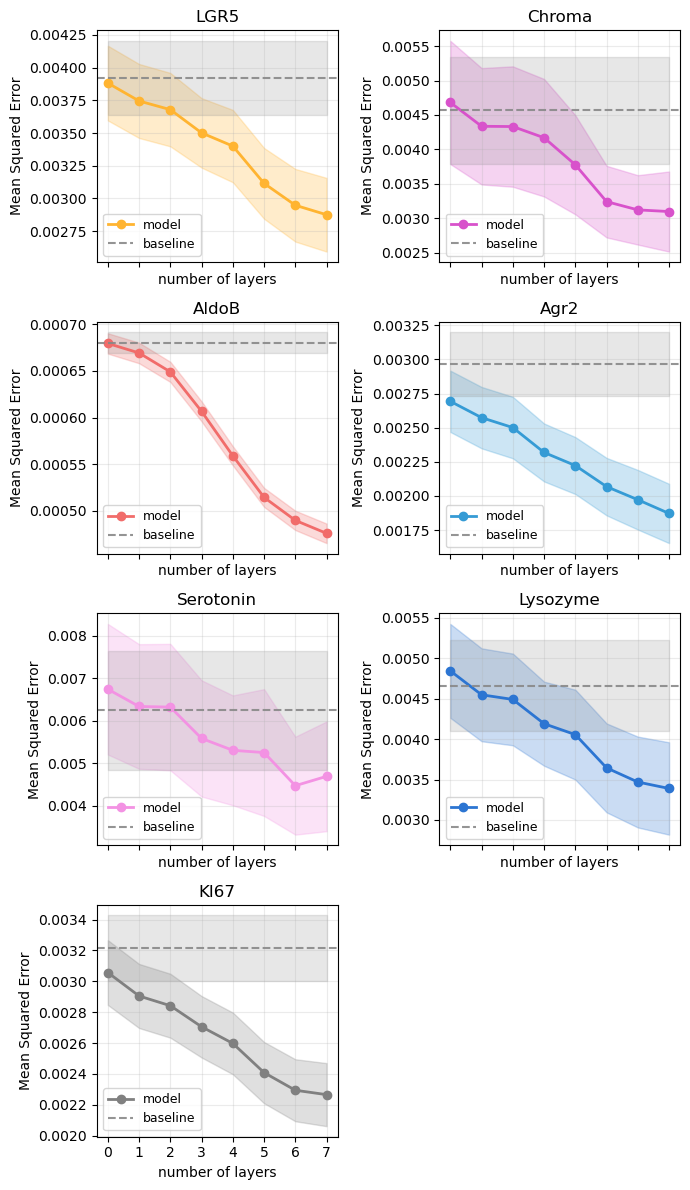

In [ ]:
import math

plt.rcParams.update({
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

n_sel = len(selected_idx)

n_cols = 2
n_rows = math.ceil(n_sel / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(7, 3 * n_rows),
    sharex=True,
)

axes = np.atleast_1d(axes).ravel()

for ax, mi, mname in zip(axes, selected_idx, selected_marker_names):

    c = get_marker_color(mname)

    y = all_mse_model[:, mi]
    s = all_sem_mse_model[:, mi]
    x = num_layers

    ax.plot(x, y, "-o", linewidth=2, color=c, label="model")
    ax.fill_between(x, y - s, y + s, color=c, alpha=0.25)

    y0 = all_mse_base[mi]
    s0 = all_sem_mse_base[mi]

    ax.axhline(y0, linestyle="--", color=baseline_color, alpha=0.9, label="baseline")
    ax.fill_between(x, y0 - s0, y0 + s0, color=baseline_color, alpha=0.2)

    ax.set_title(mname)
    ax.set_ylabel("Mean Squared Error")
    ax.set_xlabel("number of layers")
    ax.set_xticks(x)
    ax.legend(fontsize=9)

for ax in axes[n_sel:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

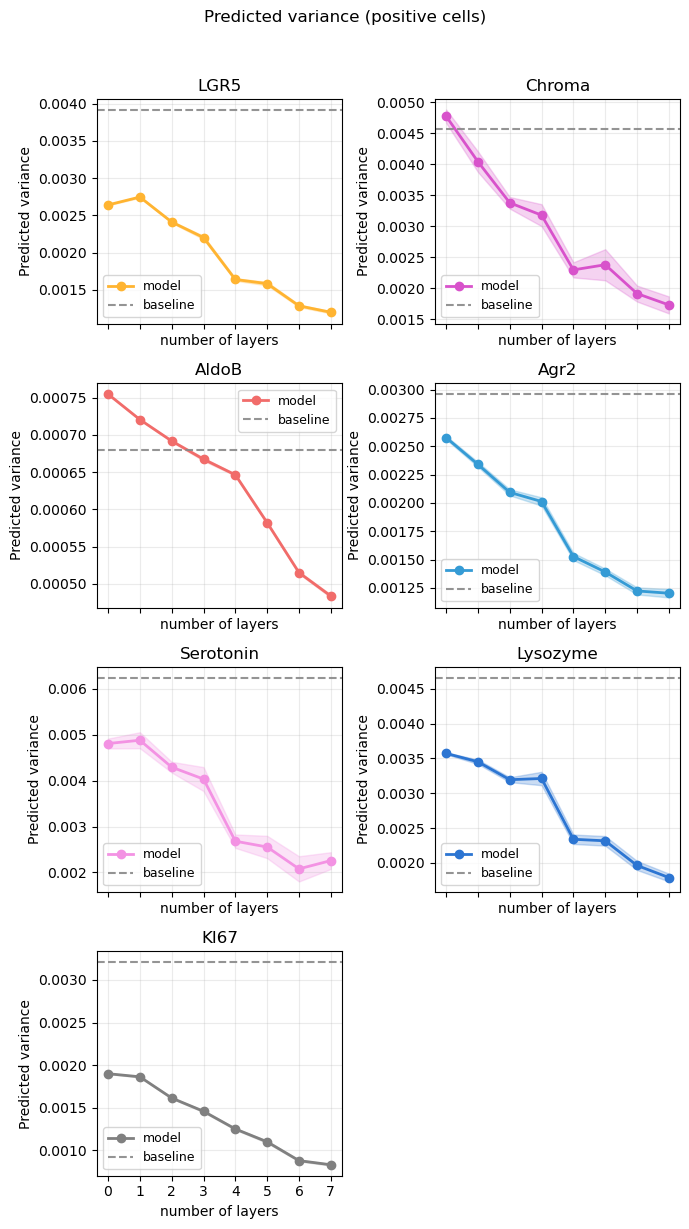

In [ ]:
n_sel = len(selected_idx)

n_cols = 2
n_rows = math.ceil(n_sel / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(7, 3 * n_rows),
    sharex=True,
)

axes = np.atleast_1d(axes).ravel()

for ax, mi, mname in zip(axes, selected_idx, selected_marker_names):

    c = get_marker_color(mname)

    y = all_var_model[:, mi]
    s = all_sem_var_model[:, mi]

    ax.plot(num_layers, y, "-o", linewidth=2, color=c, label="model")
    ax.fill_between(num_layers, y - s, y + s, color=c, alpha=0.25)

    y0 = all_var_base[mi]
    ax.axhline(y0, linestyle="--", linewidth=1.5,
               color=baseline_color, alpha=0.9, label="baseline")

    ax.set_title(mname)
    ax.set_ylabel("Predicted variance")
    ax.set_xlabel("number of layers")
    ax.set_xticks(num_layers)
    ax.legend(fontsize=9)

for ax in axes[n_sel:]:
    ax.set_visible(False)

fig.suptitle("Predicted variance (positive cells)", y=1.02)
plt.tight_layout()
plt.show()